# Ligand-Receptor Interaction Correlation (LRIC)


In this tutorial, we introduce LRIC, a weighted second-order spatial statistic in which pairwise contributions are weighted by ligand and receptor expression levels across a range of distances (annuli). 

LRIC builds on the cross pair-correlation function (cross-PCF; see also [Baddeley et al., 2016](https://www.jstatsoft.org/htaccess.php?volume=075&type=b&issue=02&filename=paper) and [Bull et al., 2024](https://www.biorxiv.org/content/10.1101/2024.12.06.627195)) by additionally weighting every cell by its ligand and receptor expression.
<br>

<img src="LRIC_summary.png" width=1000 />

## Environement Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scanpy as sc
from pathlib import Path
from itertools import islice

import liana as li



import warnings
warnings.filterwarnings("ignore")

### Dataset

We use Xenium 5K spatial transcriptomics samples from [McGregor et al., 2025, *Spatial fibroblast niches define Crohn's fistulae*, Nature](https://doi.org/10.1038/s41586-025-09744-y), a subcellular-resolution spatial atlas of intestinal fistulae in Crohn's disease. Samples are annotated by tissue `TYPE` (healthy control, ulcer, fistula) and `LOCATION` (colon, ileum), with cell types provided under `CellAnnotation.Level0`.

The helper below loads one sample: it keeps annotated cells, filters low-count cells/genes, stores raw counts, normalises and log-transforms expression, and subsets to highly variable genes.

In [ ]:
def load_crohn_slide(
    sample_id: str,
    data_dir: str = "/g/stegle/aalsayah/repos/data/xenium5k/agne_cd",
    n_top_genes: int = 3000,
    labels_key: str = "CellAnnotation.Level0",
):
    adata = sc.read_h5ad(Path(data_dir) / f"{sample_id}.h5ad")
    adata.obs_names_make_unique()
    # Keep cells with available annotations.
    adata = adata[adata.obs[labels_key].notna()].copy()

    sc.pp.filter_cells(adata, min_counts=3)
    sc.pp.filter_genes(adata, min_counts=3)

    adata.obs[labels_key] = adata.obs[labels_key].astype("category")
    adata.obsm["spatial"] = adata.obs[["x", "y"]].values

    # Preserve raw counts before normalization and log transformation.
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    sc.pp.highly_variable_genes(
        adata,
        layer="counts",
        flavor="seurat_v3",
        n_top_genes=min(n_top_genes, adata.n_vars),
        subset=True,
    )
    return adata

## Ligand–Receptor Database

In [11]:
resource = li.rs.select_resource('consensus')
print(f"{len(resource)} LR pairs in resource")
resource.head(5)

4624 LR pairs in resource


,ligand,receptor
0,LGALS9,PTPRC
1,LGALS9,MET
2,LGALS9,CD44
3,LGALS9,LRP1
4,LGALS9,CD47


## LRIC analysis - single sample

### Load and Process Data

In [54]:
data_dir = Path("/g/stegle/aalsayah/repos/data/xenium5k/agne_cd")

sample_id = "RUN3_SLIDE1_S4"


adata = load_crohn_slide(
        sample_id=sample_id,
        data_dir=str(data_dir),
    )

In [55]:
adata

AnnData object with n_obs × n_vars = 113833 × 3000
    obs: 'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_counts'
    var: 'features', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    obsm: 'X_umap', 'spatial'
    layers: 'counts'

In [56]:
### set variables

spatial_key = "spatial"
cell_type_key = "CellAnnotation.Level0"
SAMPLE_ID = "SAMPLE"
TYPE = "TYPE" #HC, ULCER, FISTULA
LOCATION = "LOCATION" #COLON, ILEUM    

... storing 'SAMPLE' as categorical
... storing 'TYPE' as categorical
... storing 'LOCATION' as categorical
... storing 'CellAnnotation.Level3' as categorical


<Axes: title={'center': 'TYPE: FISTULA, location: COLON'}, xlabel='spatial1', ylabel='spatial2'>

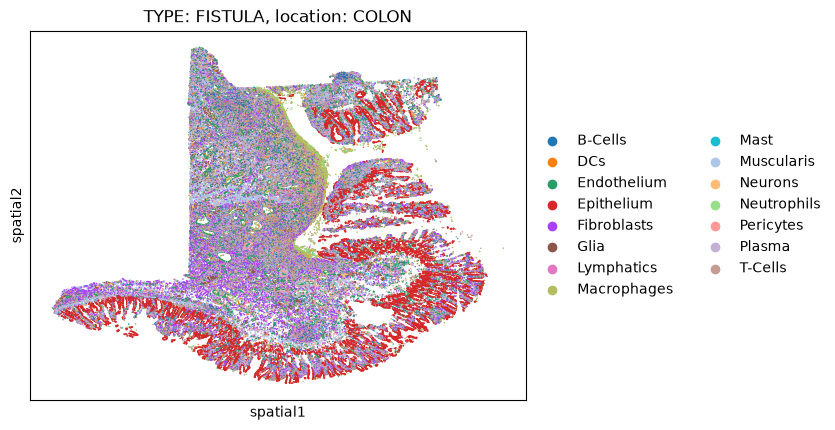

In [57]:
sc.pl.embedding(
        adata,
        basis=spatial_key,
        color=cell_type_key,
        show=False,
        s=5,
        title=f"TYPE: {adata.obs['TYPE'].unique()[0]}, location: {adata.obs['LOCATION'].unique()[0]}",
    )

### Choose the right parameters

All distance parameters are in the same units as the spatial coordinates **µm** for this MERFISH dataset. <br>
**radius_step** = step between bin inner edges (e.g. 20-25 µm, the typical upper bound of the diameter of generic cells; though this might vary a lot depending on the tissue and cell types!). <br>
**annulus_width** = radial width of each annulus ring. <br>
Setting `annulus_width = radius_step` ensures bins are non-overlapping and tile the full range without gaps. <br>
**max_radius** = inner edge of the last (widest) bin; the outer edge extends to `max_radius + annulus_width`. <br>

In [3]:
annulus_width = 20
radius_step = 20

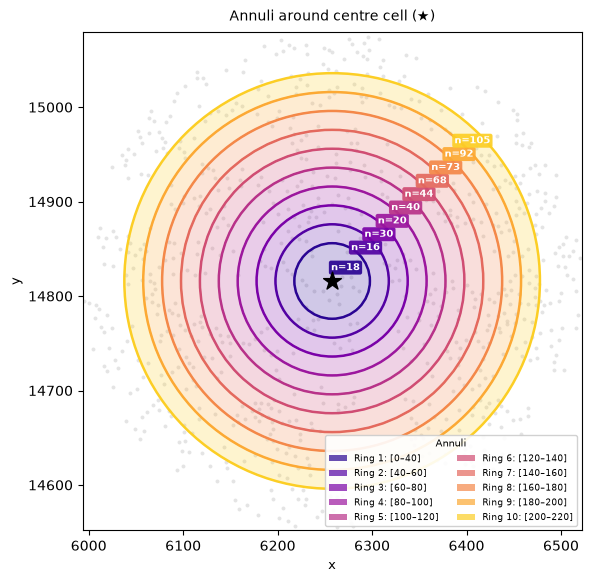

In [62]:
li.pl.annulus_plot(
    adata,
    spatial_key=spatial_key,
    annulus_width=annulus_width,
    radius_step=radius_step,
    n_rings=10,
    seed=5,
    figure_size= (6, 6))

Note that, by default (`extend_first_annulus=True`), the innermost `[0, radius_step)` contact band is merged **into the first annulus**, which therefore spans `[0, radius_step + annulus_width)` and starts at radius 0. Distances are measured from each **focal cell's centroid**, so cell centroids cannot lie closer than ~one cell diameter; the innermost band is otherwise a thin, near-empty, high-variance bin. Merging it folds genuine cell–cell contact pairs into the first bin instead of discarding them. Set `extend_first_annulus=False` to keep the first ring at `[radius_step, radius_step + annulus_width)`.

### Cross-PCF: Baseline Spatial Structure

Cross-PCF answers a **purely spatial** question:

> Are cells of type B more (or less) frequent around cells of type A at distance r than expected under complete spatial randomness?

It treats all cells **equally**. Gene expression is not considered. We use it to characterise the raw spatial architecture of the tissue before asking about LR interactions.

In [166]:
li.mt.cross_pcf(
    adata,
    groupby=cell_type_key,
    spatial_key=spatial_key,
    max_radius=200,
    radius_step=radius_step,
    annulus_width=annulus_width,
    key_added="cross_pcf", #results will be saved under this label in adata.uns
    verbose=True,
)

`min_cells=None`: dropping cell types with <= 1.0% of 113833 cells (min_cells=1139).
Using `.X`!
The following cell identities were excluded: Mast, Neurons, Neutrophils


Computing cross-PCF for 12 cell types (132 directed pairs).
cross-PCF: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [00:04<00:00, 26.95it/s]


In [167]:
## Explore the output:
print(adata.uns["cross_pcf"].keys())
cross_pcf_res = adata.uns["cross_pcf"]

print(dict(islice(cross_pcf_res["results"].items(), 5)))

dict_keys(['cell_types', 'radii', 'results'])
{('B-Cells', 'DCs'): array([1.51875691, 1.46162849, 1.42740281, 1.42383012, 1.41581784,
       1.41052121, 1.40599464, 1.37066264, 1.36892445, 1.34731248]), ('B-Cells', 'Endothelium'): array([0.91450664, 1.01814369, 1.05888538, 1.07551072, 1.08057113,
       1.07930643, 1.10089874, 1.12260639, 1.12799977, 1.12789917]), ('B-Cells', 'Epithelium'): array([0.19938826, 0.30522187, 0.35131129, 0.37936909, 0.37532759,
       0.38407965, 0.38069963, 0.38958926, 0.39602102, 0.40696009]), ('B-Cells', 'Fibroblasts'): array([1.06762435, 1.06714892, 1.0811011 , 1.0851654 , 1.09011769,
       1.10959091, 1.10551202, 1.09383674, 1.09785493, 1.09432178]), ('B-Cells', 'Glia'): array([0.67746433, 0.7762704 , 0.82750457, 0.84991739, 0.89891907,
       0.91855454, 0.92347082, 0.96589232, 0.98014607, 1.00298942])}


In [196]:
def short_range_summary(block, modality, max_dist=50, direction="both",
                        g_hi=1.0, g_lo=1.0, dedup=None):
    """Short-range enrichment/depletion per pair for cross_pcf | lric_ag | lric_ct."""
    radii = np.asarray(block["radii"], float)
    nr = radii.size

    if modality == "cross_pcf":                              # {(a,b): curve}
        results = {k: np.asarray(v, float) for k, v in block["results"].items()}
    elif modality == "lric_ag":                              # matrix (radii, pairs)
        mat = next(np.asarray(v, float) for v in block.values() if np.ndim(v) == 2)
        mat = mat if mat.shape[0] == nr else mat.T
        results = {n: mat[:, j] for j, n in enumerate(block["pair_names"])}
    elif modality == "lric_ct":                              # {(a,b): matrix (radii, pairs)}
        names = block["pair_names"]
        results = {}
        for (a, b), m in block["results"].items():
            m = np.asarray(m, float)
            m = m if m.shape[0] == nr else m.T               # -> (radii, pairs)
            for j, p in enumerate(names):
                results[(a, b, p)] = m[:, j]
    else:
        raise ValueError(f"unknown modality: {modality!r}")

    win = radii < max_dist
    rw = radii[win]
    dedup = (modality == "cross_pcf") if dedup is None else dedup

    def collect(reduce, keep, sign):
        hits = {}
        for k, g in results.items():
            gw = g[win]
            i = reduce(gw)
            if keep(gw[i]):
                hits[k] = (float(rw[i]), float(gw[i]))
        hits = dict(sorted(hits.items(), key=lambda kv: sign * kv[1][1]))
        if dedup:
            seen = set()
            hits = {k: v for k, v in hits.items()
                    if frozenset(k) not in seen and not seen.add(frozenset(k))}
        return hits

    enrich  = collect(np.argmax, lambda v: v > g_hi, -1)
    deplete = collect(np.argmin, lambda v: v < g_lo, +1)
    return {"enrich": enrich, "deplete": deplete}[direction] if direction != "both" \
        else {"enrich": enrich, "deplete": deplete}

In [245]:

def _expr(gene):
    g = [x for x in str(gene).split("_") if x in adata.var_names]
    X = adata[:, g].X
    return (X.toarray() if hasattr(X, "toarray") else np.asarray(X)).min(1)

def plot_pair(a, b, curves, modality="cross_pcf", colors=None, title=None,
              snd=None, rcv=None, cell_type_key="cell_type", spatial_key="spatial"):
    xy = adata.obsm[spatial_key]

    def cat_panel(ax, s, r):
        ct = adata.obs[cell_type_key].astype(str).values
        sm, rm = ct == s, ct == r
        ax.scatter(*xy[~(sm|rm)].T, s=2, c="lightgray", alpha=.1, lw=0, rasterized=True)
        ax.scatter(*xy[rm].T, s=6,  c="tab:orange", alpha=.6, lw=0, rasterized=True, label=f"{r} (n={rm.sum():,})")
        ax.scatter(*xy[sm].T, s=10, c="tab:green",  alpha=.9, lw=0, rasterized=True, label=f"{s} (n={sm.sum():,})")
        ax.legend(frameon=False, fontsize=9, loc="upper left", bbox_to_anchor=(0, -.02))
        ax.set_aspect("equal"); ax.axis("off"); ax.set_title(f"{s} & {r}")

    def expr_panel(ax, gene, cmap):
        v = _expr(gene); msk = v > 0
        ax.scatter(*xy.T, s=2, c="lightgray", alpha=.1, lw=0, rasterized=True)
        sc = ax.scatter(*xy[msk].T, s=6, c=v[msk], cmap=cmap, alpha=.7, lw=0, rasterized=True)
        fig.colorbar(sc, ax=ax, shrink=.6)
        ax.set_aspect("equal"); ax.axis("off"); ax.set_title(gene)

    panels = []
    if modality == "cross_pcf":
        panels.append(lambda ax: cat_panel(ax, a, b))
    else:
        if snd and rcv:                                  # lric_ct: add cell-type map
            panels.append(lambda ax: cat_panel(ax, snd, rcv))
        panels.append(lambda ax: expr_panel(ax, a, "Greens"))
        panels.append(lambda ax: expr_panel(ax, b, "Oranges"))

    n = len(panels) + 1
    ratios = [0.8] * len(panels) + [1] 
    fig, ax = plt.subplots(1, n, figsize=(5*n, 4), layout="constrained",
                           gridspec_kw={"width_ratios": ratios})
    fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)
    for draw, axi in zip(panels, ax):
        draw(axi)
    li.pl.lric_lineplot(None, curves, overlay=True, colors=colors, title=title, ax=ax[-1])
    plt.show()

`short_range_summary` scans every directed cell-type pair and keeps, for each, its strongest g(r) peak or trough within `max_dist` (here 50 µm), a quick way to rank hundreds of pairs before plotting individual curves.

#### Aggregation: cells cluster together at a short distance

Example: `Endothelium ↔ Pericytes` is the top hit below (g≈1.6 at 0 µm) — pericytes physically wrap endothelial cells, so cross-PCF recovers this known perivascular architecture.

In [246]:
summary = short_range_summary(adata.uns["cross_pcf"], "cross_pcf", max_dist=50)

for dirn, word in [("enrich", "peak"), ("deplete", "trough")]:
    print(f"\n=== cross_pcf — {dirn} (top 5) ===")
    for (a, b), (r, g) in islice(summary[dirn].items(), 5):
        print(f"  {a:>15} → {b:<15} {word} g={g:.2f} @ {r:.0f}um")


=== cross_pcf — enrich (top 5) ===
          B-Cells → T-Cells         peak g=1.95 @ 0um
          B-Cells → Plasma          peak g=1.77 @ 0um
      Endothelium → Pericytes       peak g=1.62 @ 0um
              DCs → Plasma          peak g=1.54 @ 0um
          B-Cells → DCs             peak g=1.52 @ 0um

=== cross_pcf — deplete (top 5) ===
       Epithelium → Pericytes       trough g=0.12 @ 0um
       Epithelium → Muscularis      trough g=0.15 @ 0um
       Epithelium → Glia            trough g=0.17 @ 0um
          B-Cells → Epithelium      trough g=0.20 @ 0um
       Epithelium → Lymphatics      trough g=0.22 @ 0um


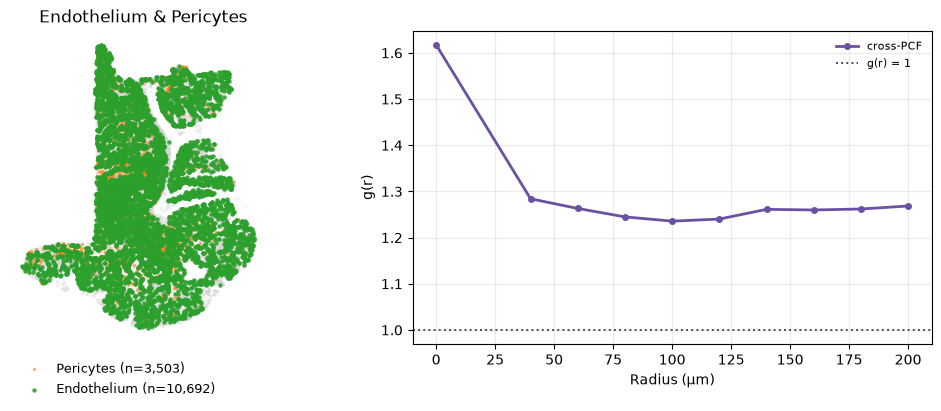

In [247]:
r = lambda x: np.asarray(x, float)

# cross_pcf
plot_pair("Endothelium", "Pericytes",
          {"cross-PCF": (r(cross_pcf_res["radii"]), r(cross_pcf_res["results"][("Endothelium","Pericytes")]))},
          colors="#6A51A3", cell_type_key=cell_type_key, spatial_key=spatial_key)

#### Exclusion: cells avoid each other

Example: `Epithelium ↔ B-Cells` is the strongest depletion above (g≈0.2 at 0 µm), epithelial cells form a contiguous barrier layer that B cells rarely penetrate, so the two populations stay spatially segregated.

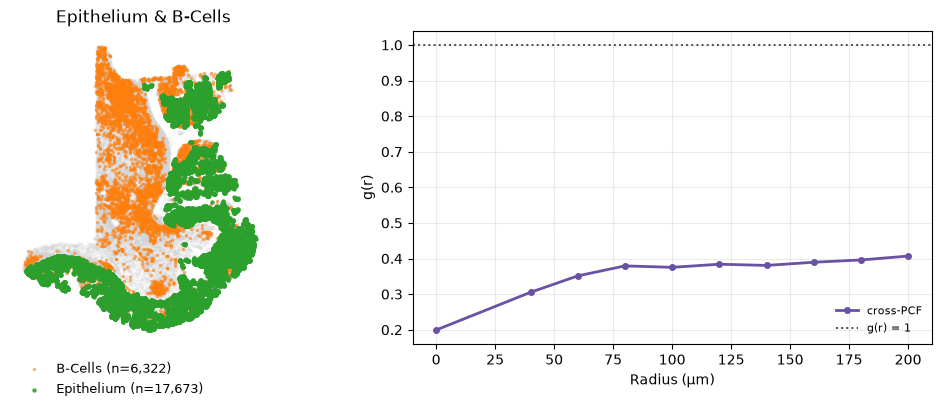

In [248]:
r = lambda x: np.asarray(x, float)

# cross_pcf
plot_pair("Epithelium", "B-Cells",
          {"cross-PCF": (r(cross_pcf_res["radii"]), r(cross_pcf_res["results"][("Epithelium","B-Cells")]))},
          colors="#6A51A3", cell_type_key=cell_type_key, spatial_key=spatial_key)

### Ligand–Receptor Global Co-expression using LRIC

The agnostic mode of LRIC answer questions like:

> Across all cells in the tissue, is the ligand signal spatially enriched around receptor-expressing receiver cells at distance r?

In [174]:
li.mt.lric(
    adata,
    resource=resource,
    spatial_key=spatial_key,
    max_radius=200,
    radius_step=radius_step,
    annulus_width=annulus_width,
    use_raw=False,
    key_added="lric_ag",  #results will be saved under this label in adata.uns
    verbose=True,
)

Using `.X`!


Using provided `resource`.


Running cell-type-agnostic LRIC.


In [205]:
## Explore the output:
print(adata.uns["lric_ag"].keys())
lric_ag_res = adata.uns["lric_ag"]

dict_keys(['pair_names', 'radii', 'lric'])


Same idea as before, now ranking all 4,624 ligand–receptor pairs (regardless of cell type) by their strongest short-range enrichment/depletion — candidate global LR co-localisation signals.

In [206]:
summary = short_range_summary(adata.uns["lric_ag"], "lric_ag", max_dist=50)

for dirn, word in [("enrich", "peak"), ("deplete", "trough")]:
    print(f"\n=== lric_ag — {dirn} (top 5) ===")
    for name, (r, g) in islice(summary[dirn].items(), 5):
        print(f"  {name:<22} {word} g={g:.2f} @ {r:.0f}um")


=== lric_ag — enrich (top 5) ===
  CXCL5^CXCR1            peak g=8.09 @ 40um
  CXCL5^CXCR2            peak g=7.68 @ 0um
  IL2^IL2RA_IL2RB_IL2RG  peak g=6.86 @ 40um
  CCL22^CCR4             peak g=6.72 @ 0um
  IL21^IL21R_IL2RG       peak g=6.39 @ 0um

=== lric_ag — deplete (top 5) ===
  EBI3_IL12A^IL12RB2_IL6ST trough g=0.00 @ 0um
  PENK^OPRK1             trough g=0.00 @ 0um
  TG^LRP2                trough g=0.00 @ 40um
  GCG^ADRB2              trough g=0.00 @ 40um
  GCG^PTH1R              trough g=0.00 @ 0um


Example: `CXCL5 → CXCR1` shows the strongest global enrichment (g≈8 at 40 µm) — chemokine ligand and receptor co-occur at short range far more than expected, consistent with localised neutrophil-recruiting signalling.

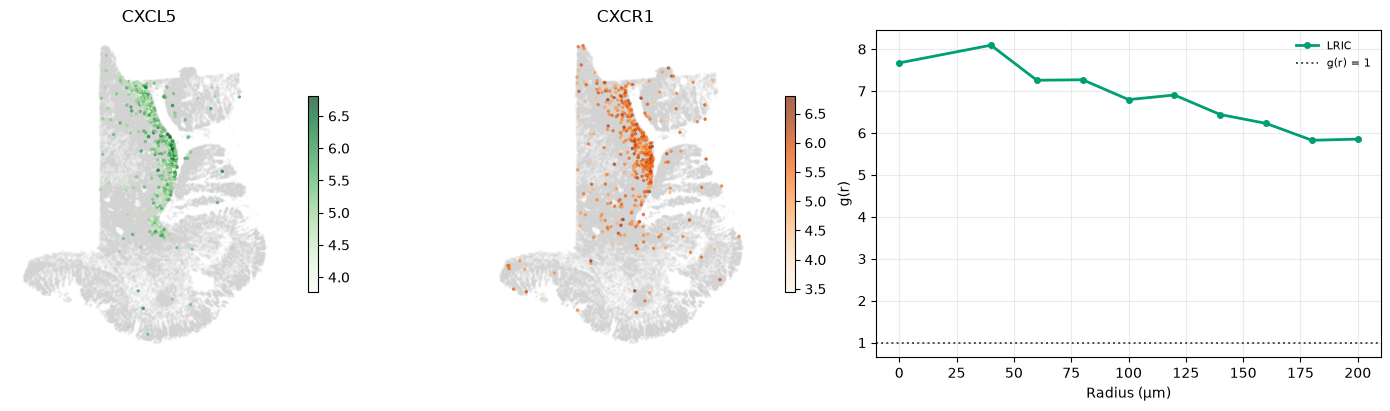

In [249]:
mat = next(np.asarray(v, float) for v in lric_ag_res.values() if np.ndim(v)==2)
mat = mat if mat.shape[0]==len(lric_ag_res["radii"]) else mat.T
lig, rec = "CXCL5^CXCR1".split("^")
plot_pair(lig, rec,
          {"LRIC": (np.asarray(lric_ag_res["radii"], float),
                    mat[:, lric_ag_res["pair_names"].index("CXCL5^CXCR1")])},
          modality="lric_ag", colors="#009E73", spatial_key=spatial_key)

Example: `PENK → OPRK1` is among the strongest depletions (g≈0) — ligand and receptor are each detected somewhere in the tissue, but rarely at short range from each other, illustrating that global co-expression doesn't guarantee spatial proximity.

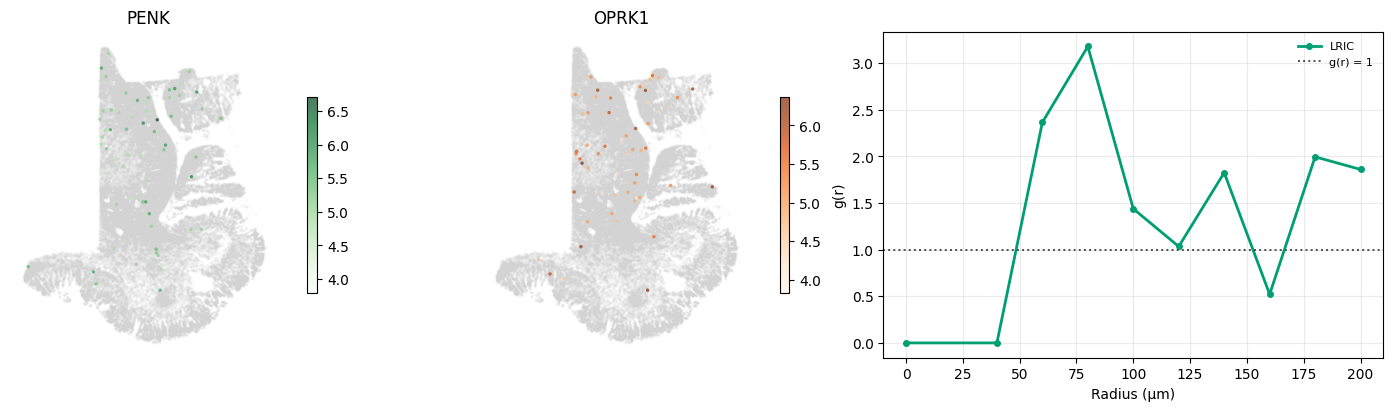

In [21]:
lig, rec = "PENK^OPRK1".split("^")
plot_pair(lig, rec,
          {"LRIC": (np.asarray(lric_ag_res["radii"], float),
                    mat[:, lric_ag_res["pair_names"].index("PENK^OPRK1")])},
          modality="lric_ag", colors="#009E73", spatial_key=spatial_key)

### LRIC Cell-Type Informed for Directed Interactions

The **cell-type-informed** mode splits cells into sender and receiver populations by cell-type annotation and computes g(r) for every directed **(sender → receiver)** pair, weighted by the LR expression.

This answers a more specific question:

> For the specific interaction **sender cell type X expressing ligand L** → **receiver cell type Y expressing receptor R**, is the LR-weighted spatial co-enrichment at distance r higher than expected?

**Key advantage over cross-PCF**: the expression weighting means g(r) > 1 can only be driven by cells that express the relevant ligand/receptor.

In [191]:
li.mt.lric(
    adata,
    resource=resource,
    groupby=cell_type_key,
    spatial_key=spatial_key,
    max_radius=200,
    radius_step=radius_step,
    annulus_width=annulus_width,
    min_expressing=20,
    use_raw=False,
    key_added="lric_ct", #results will be saved under this label in adata.uns
    verbose=True,
)

`min_cells=None`: dropping cell types with <= 1.0% of 113833 cells (min_cells=1139).
Using `.X`!
The following cell identities were excluded: Mast, Neurons, Neutrophils


Using provided `resource`.


Running LRIC (conditional within-type null) for 12 cell types (132 directed pairs).
LRIC: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [02:23<00:00,  1.08s/it]


Now the ranking is over (sender, receiver, LR pair) triplets — cell-type × cell-type × LR-pair combinations — so it surfaces the single strongest directed, expression-weighted signals in the tissue.

In [209]:
summary = short_range_summary(adata.uns["lric_ct"], "lric_ct", max_dist=50)

for dirn, word in [("enrich", "peak"), ("deplete", "trough")]:
    print(f"\n=== lric_ct — {dirn} (top 5) ===")
    for (a, b, p), (r, g) in islice(summary[dirn].items(), 5):
        print(f"  {a} → {b:<12} {p:<18} {word} g={g:.2f} @ {r:.0f}um")


=== lric_ct — enrich (top 5) ===
  T-Cells → Macrophages  IL1RN^IL1RL2       peak g=22.77 @ 40um
  B-Cells → Plasma       KITLG^KIT          peak g=17.55 @ 40um
  DCs → T-Cells      CCL19^CCR7         peak g=17.31 @ 0um
  Plasma → Glia         FGF13^FGFR1        peak g=16.01 @ 0um
  B-Cells → T-Cells      CXCL13^CXCR5       peak g=15.75 @ 0um

=== lric_ct — deplete (top 5) ===
  B-Cells → DCs          DLL1^NOTCH2        trough g=0.00 @ 40um
  B-Cells → DCs          ANXA1^FPR1         trough g=0.00 @ 40um
  B-Cells → DCs          FCER2^ITGAM_ITGB2  trough g=0.00 @ 0um
  B-Cells → DCs          FCER2^ITGAX_ITGB2  trough g=0.00 @ 0um
  B-Cells → DCs          THBS1^ITGA4        trough g=0.00 @ 40um


Example: `DCs → T-Cells` via `CCL19 → CCR7` is the top hit above (g≈17 at 0 µm) — CCR7-guided dendritic cell homing to T-cell zones is a well-established immunological mechanism. Below, we overlay all three statistics for this same DC/T-cell pair: cross-PCF (raw spatial co-localisation), LRIC agnostic (expression-weighted, cell type ignored) and LRIC cell-type-informed (expression-weighted, sender/receiver restricted) — showing how each successive layer of information sharpens the signal.

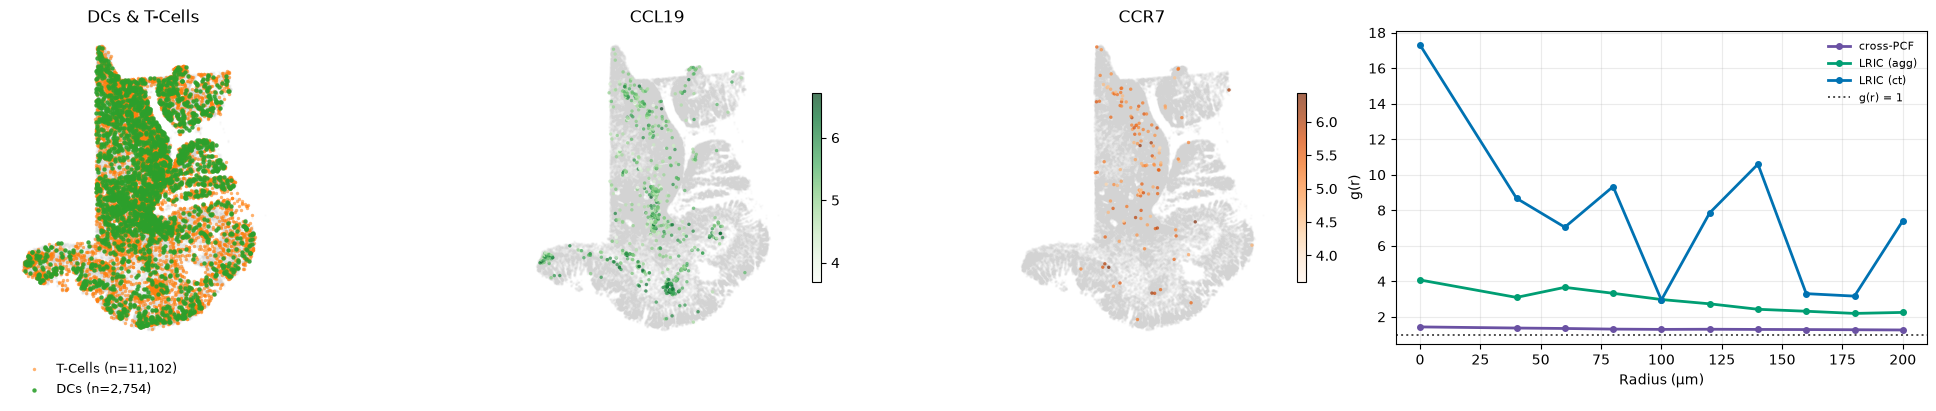

In [254]:
snd, rcv = "DCs", "T-Cells"
ligand, receptor = "CCL19", "CCR7"
pair = f"{ligand}^{receptor}"

def _col(block, key, pair=None):
    """Pull a 1D curve (radii, g) from any modality block."""
    radii = np.asarray(block["radii"], float)
    v = block["results"][key] if "results" in block else \
        next(np.asarray(x, float) for x in block.values() if np.ndim(x) == 2)
    v = np.asarray(v, float)
    if v.ndim == 2:                                   # (radii, pairs) -> pick pair
        v = v if v.shape[0] == radii.size else v.T
        v = v[:, block["pair_names"].index(pair)]
    return radii, v

curves = {
    "cross-PCF":  _col(adata.uns["cross_pcf"], (snd, rcv)),
    "LRIC (agg)": _col(adata.uns["lric_ag"],   None,        pair),
    "LRIC (ct)":  _col(adata.uns["lric_ct"],   (snd, rcv),  pair),
}

plot_pair(ligand, receptor, curves, modality="lric_ct",
          snd=snd, rcv=rcv, colors=["#6A51A3", "#009E73", "#0072B2"],
          cell_type_key=cell_type_key, spatial_key=spatial_key)

----

## Multi-sample analysis


Having validated the three statistics (cross-PCF, LRIC agnostic, LRIC cell-type-informed) on one slide, we now ask whether they differ systematically **between conditions**. We load 6 samples — 3 healthy control (HC) and 3 fistula — run the same three analyses on each with identical parameters (so curves are directly comparable across samples), and compare the resulting g(r) curves across samples using two complementary summary statistics (below). `spatial_key`, `cell_type_key`, `resource`, `radius_step` and `annulus_width` are reused from the single-sample setup above.

In [ ]:
sample_ids = ["RUN1_SLIDE1_S3", "RUN2_SLIDE1_S5", "RUN1_SLIDE1_S2", "RUN3_SLIDE1_S4", "RUN3_SLIDE1_S7", "RUN3_SLIDE1_S5"]  # 3 HC vs. 3 FISTULA
data_dir = "/g/stegle/aalsayah/repos/data/xenium5k/agne_cd"

adata_list = [load_crohn_slide(sample_id=sid, data_dir=data_dir) for sid in sample_ids]

### Run cross PCF and LRIC

In [12]:
for ad in adata_list:
    li.mt.cross_pcf(ad, 
            groupby=cell_type_key,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            key_added="cross_pcf")

    li.mt.lric(
            ad,
            resource=resource,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            use_raw=False,
            key_added="lric_ag",  #results will be saved under this label in adata.uns
            verbose=True,
        )

    li.mt.lric(
            ad,
            resource=resource,
            groupby=cell_type_key,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            min_expressing=20,
            use_raw=False,
            key_added="lric_ct", #results will be saved under this label in adata.uns
            verbose=True,
        )

Using `.X`!


Using provided `resource`.


Running cell-type-agnostic LRIC.
`min_cells=None`: dropping cell types with <= 1.0% of 103899 cells (min_cells=1039).
Using `.X`!
The following cell identities were excluded: B-Cells, Lymphatics, Neurons, Neutrophils


Using provided `resource`.


Running LRIC (conditional within-type null) for 11 cell types (110 directed pairs).
LRIC: 100%|█████████████████████████████████████████████████████████████████████████████████████| 110/110 [02:28<00:00,  1.35s/it]
Using `.X`!


...

Running LRIC (conditional within-type null) for 12 cell types (132 directed pairs).
LRIC: 100%|█████████████████████████████████████████████████████████████████████████████████████| 132/132 [00:44<00:00,  2.96it/s]
Using `.X`!


Using provided `resource`.


Running cell-type-agnostic LRIC.
`min_cells=None`: dropping cell types with <= 1.0% of 81825 cells (min_cells=819).
Using `.X`!
The following cell identities were excluded: Neurons


Using provided `resource`.


Running LRIC (conditional within-type null) for 14 cell types (182 directed pairs).
LRIC: 100%|█████████████████████████████████████████████████████████████████████████████████████| 182/182 [01:24<00:00,  2.15it/s]


In [13]:
import pickle

# Save
with open("adata_list_crohns.pkl", "wb") as f:
    pickle.dump(adata_list, f)

In [ ]:
with open("adata_list_crohns.pkl", "rb") as f:
    adata_list = pickle.load(f)

### Cross sample comparisons

### 1. Summary scores

**How it works:** for every feature — a cell-type pair (cross-PCF), an LR pair (LRIC agnostic), or a sender→receiver→LR triplet (LRIC cell-type-informed) — each sample's g(r) curve is log2-transformed and collapsed to a single number: the area under the curve (AUC) out to `max_radius`. This turns "does this spatial relationship differ between conditions" into a plain two-group comparison, one AUC value per sample per feature. We then run a Mann-Whitney U test (FISTULA vs. HC) per feature, rank by effect size (rank-biserial correlation), and correct for multiple testing with BH-FDR.

**Benefits:** non-parametric and robust to the small sample sizes typical of spatial cohorts (n=3 per group here); collapsing each curve to one number lets thousands of features be ranked and tested with standard statistics; and it directly answers *which* spatial relationships shift between conditions overall, independent of *where* along r the shift happens.

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

In [ ]:
# ---- config --------------------------------------
AUC_FLOOR = 0.05                              # floor before log2, avoids log2(0)
HALF      = annulus_width / 2                 # radii -> annulus bin centres
OBS       = dict(sample="SAMPLE", type="TYPE")  # obs columns
COLORS    = {"FISTULA": "#009E73", "HC": "#6A51A3"}
TOP_N = 5

# ---- core -----------------------------------------------------------------
def _log2g(curve):
    """log2 g(r), floored to avoid log2(0)."""
    return np.log2(np.maximum(np.asarray(curve, float), AUC_FLOOR))

def _features(adata, modality):
    """Yield (feature_key, 1D curve) for one modality block."""
    d, r = adata.uns[modality], np.asarray(adata.uns[modality]["radii"], float)
    if modality == "cross_pcf":               # key=(A,B); symmetric -> keep one dir
        seen = set()
        for k, c in d["results"].items():
            if frozenset(k) not in seen and not seen.add(frozenset(k)):
                yield k, np.asarray(c, float).ravel()
    elif modality == "lric_ag":               # key='L^R'
        M = np.asarray(d["lric"], float); M = M if M.shape[0] == r.size else M.T
        for j, lr in enumerate(d["pair_names"]):
            yield lr, M[:, j]
    elif modality == "lric_ct":               # key=((A,B),'L^R')
        for k, arr in d["results"].items():
            A = np.asarray(arr, float); A = A if A.shape[0] == r.size else A.T
            for j, lr in enumerate(d["pair_names"]):
                yield (k, lr), A[:, j]

def _auc(curve, radii):
    y = _log2g(curve)
    x = np.asarray(radii, float) + HALF
    m = np.isfinite(x) & np.isfinite(y)
    return np.trapezoid(y[m], x[m]) if m.sum() >= 3 else np.nan

def _label(feat, modality):
    if modality == "cross_pcf": return f"{feat[0]} ↔ {feat[1]}"
    if modality == "lric_ag":   return feat.replace("^", " → ")
    (a, b), lr = feat;          return f"{a} → {b}\n{lr.replace('^', ' → ')}"

def auc_table(adata_list, modality):
    """Long table: one row per (sample, feature) with its AUC(log2 g)."""
    rows = []
    for ad in adata_list:
        meta = {k: str(ad.obs[c].iloc[0]) for k, c in OBS.items()}
        radii = np.asarray(ad.uns[modality]["radii"], float)
        for key, curve in _features(ad, modality):
            rows.append({**meta, "feature": key, "auc": _auc(curve, radii)})
    return pd.DataFrame(rows)

def compare(df, a="FISTULA", b="HC", min_n=2):
    """Per-feature Mann-Whitney a vs b + BH-FDR, sorted by |rank-biserial|."""
    out = []
    for feat, g in df.groupby("feature", sort=False):
        xa = g.loc[g.type == a, "auc"].dropna().values
        xb = g.loc[g.type == b, "auc"].dropna().values
        if len(xa) < min_n or len(xb) < min_n:
            continue
        u = mannwhitneyu(xa, xb, alternative="two-sided")
        out.append(dict(feature=feat, rb=2*u.statistic/(len(xa)*len(xb)) - 1, p=u.pvalue,
                        **{f"mean_{a}": xa.mean(), f"mean_{b}": xb.mean(),
                           f"n_{a}": len(xa), f"n_{b}": len(xb)}))
    res = pd.DataFrame(out)
    res["padj"] = multipletests(res["p"], method="fdr_bh")[1] if len(res) else None
    return res.iloc[res.rb.abs().argsort()[::-1]].reset_index(drop=True)

def plot_top(df, res, modality, top_n=TOP_N, a="FISTULA", b="HC", seed=0):
    """Boxplot grid of the top-N features; colour=type, point=sample."""
    top = res.head(top_n); ncol = min(5, len(top)); nrow = int(np.ceil(len(top)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2*ncol, 3.5*nrow), squeeze=False)
    rng = np.random.default_rng(seed)
    for ax, (_, row) in zip(axes.ravel(), top.iterrows()):
        sub = df[df.feature == row.feature]
        data = [sub.loc[sub.type == g, "auc"].dropna().values for g in (a, b)]
        bp = ax.boxplot(data, tick_labels=[a, b], widths=.5, showfliers=False, patch_artist=True)
        for patch, g in zip(bp["boxes"], (a, b)):
            patch.set_facecolor(COLORS[g]); patch.set_alpha(.25)
        for med in bp["medians"]: med.set_color("black")
        for x, g in enumerate((a, b), 1):
            for _, rr in sub[sub.type == g].iterrows():
                if np.isfinite(rr.auc):
                    ax.scatter(x + rng.uniform(-.08, .08), rr.auc, s=45, zorder=3,
                               marker="o", color=COLORS[g], edgecolor="black", lw=.4)
        ax.axhline(0, color="grey", ls="--", lw=.8)
        ax.set_title(f"{_label(row.feature, modality)}\n"
                     f"rb={row.rb:.2f} p={row.p:.2g} padj={row.padj:.2g}", fontsize=8)
        ax.set_ylabel("AUC of log2 g(r)", fontsize=8); ax.tick_params(labelsize=8)
    for ax in axes.ravel()[len(top):]: ax.set_visible(False)
    th = [plt.Line2D([0],[0], marker="o", ls="none", mfc=COLORS[g], mec="black", label=g) for g in (a, b)]
    fig.legend(handles=th, title="Type", loc="upper right", bbox_to_anchor=(1, 1), frameon=False)
    fig.suptitle(f"{modality} — top {len(top)} by {a} vs {b}", y=1.02)
    fig.tight_layout(rect=[0, 0, .9, 1]); return fig

The boxplots below show the top-5 differential features per modality, ranked by effect size, with one point per sample.

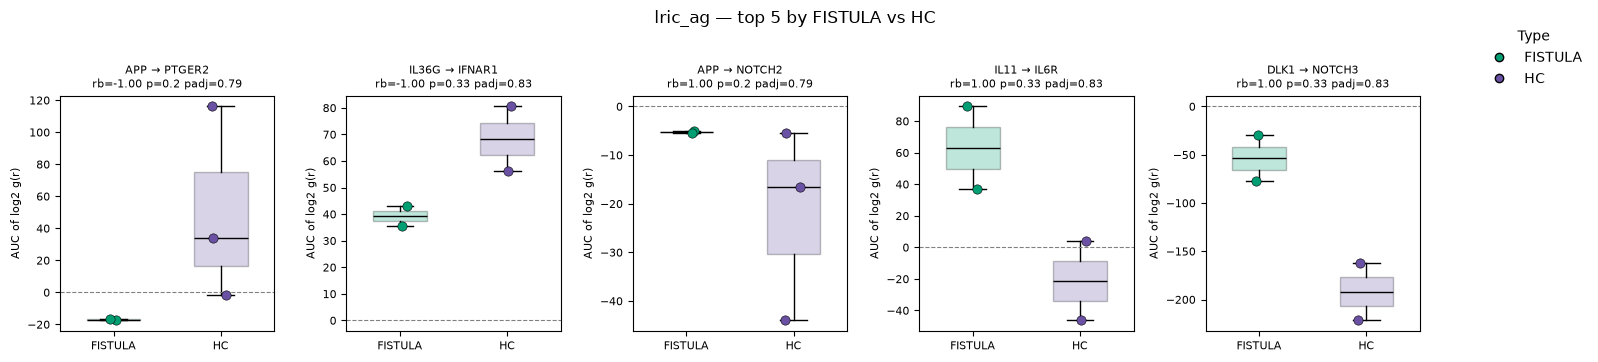

,feature,rb,p,mean_FISTULA,mean_HC,n_FISTULA,n_HC,padj
0,APP^PTGER2,-1.0,0.200000,-17.017905,49.514550,2,3,0.788235
1,IL36G^IFNAR1,-1.0,0.333333,39.280951,68.386625,2,2,0.833161
2,APP^NOTCH2,1.0,0.200000,-5.246680,-21.997294,2,3,0.788235
3,IL11^IL6R,1.0,0.333333,62.995126,-21.204106,2,2,0.833161
4,DLK1^NOTCH3,1.0,0.333333,-53.403597,-191.866336,2,2,0.833161


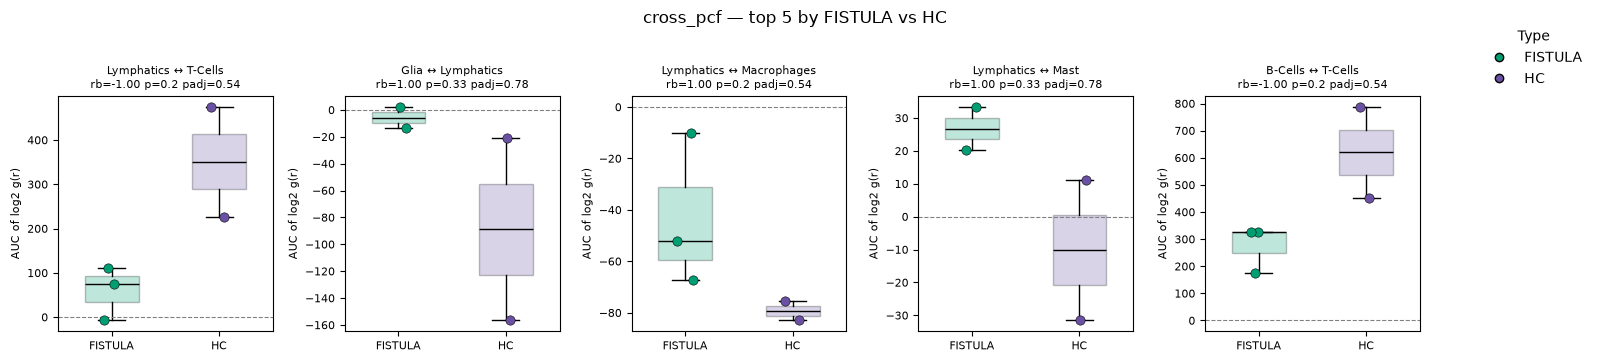

,feature,rb,p,mean_FISTULA,mean_HC,n_FISTULA,n_HC,padj
0,"(Lymphatics, T-Cells)",-1.0,0.200000,59.612250,350.709618,3,2,0.542857
1,"(Glia, Lymphatics)",1.0,0.333333,-5.764954,-88.983256,2,2,0.779487
2,"(Lymphatics, Macrophages)",1.0,0.200000,-43.128080,-79.287746,3,2,0.542857
3,"(Lymphatics, Mast)",1.0,0.333333,26.769488,-10.198404,2,2,0.779487
4,"(B-Cells, T-Cells)",-1.0,0.200000,274.887689,620.070526,3,2,0.542857


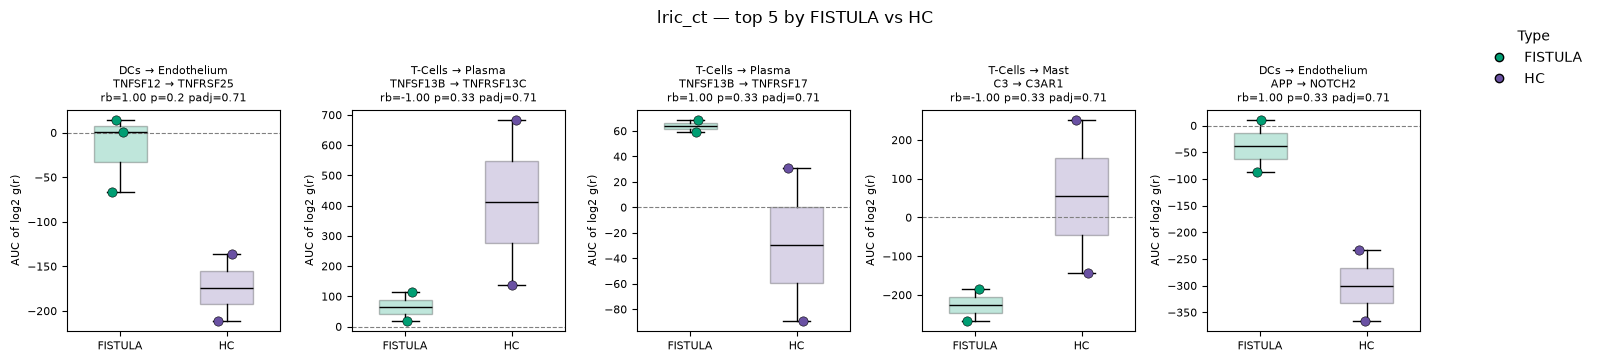

,feature,rb,p,mean_FISTULA,mean_HC,n_FISTULA,n_HC,padj
0,"((DCs, Endothelium), TNFSF12^TNFRSF25)",1.0,0.200000,-17.004065,-174.046508,3,2,0.706017
1,"((T-Cells, Plasma), TNFSF13B^TNFRSF13C)",-1.0,0.333333,65.661751,411.245287,2,2,0.706017
2,"((T-Cells, Plasma), TNFSF13B^TNFRSF17)",1.0,0.333333,64.105843,-29.389021,2,2,0.706017
3,"((T-Cells, Mast), C3^C3AR1)",-1.0,0.333333,-225.763429,54.590615,2,2,0.706017
4,"((DCs, Endothelium), APP^NOTCH2)",1.0,0.333333,-38.171391,-299.802557,2,2,0.706017


In [23]:
for modality in ["lric_ag", "cross_pcf", "lric_ct"]:
    df  = auc_table(adata_list, modality)
    res = compare(df, "FISTULA", "HC")
    plot_top(df, res, modality, top_n=TOP_N)
    plt.show()
    display(res.head(TOP_N))

### 2. Summary score

Summary score 1 collapses each curve to a single AUC number — simple, but it discards *where* along r the two groups diverge, and opposite-signed differences at different radii can cancel out. Summary score 2 instead compares the **full curves**: for each feature it takes the group-mean log2 g(r) curves for FISTULA and HC, measures the area between them (`divergence`, an L1 distance in curve-space) and the radius of maximal divergence (`r_star`), and tests significance by label permutation (shuffling the FISTULA/HC labels across samples and recomputing divergence) rather than a rank test. This is more sensitive to differences concentrated at a specific distance, at the cost of being more compute-intensive than score 1's closed-form test.

In [ ]:
import itertools

def compare_curves(adata_list, modality, a="FISTULA", b="HC", max_perm=2000, seed=0):
    """divergence = L1 area between group-mean log2 g(r); r_star = radius of max
    divergence; p = label-permutation."""
    curves, labels, x = {}, [], None
    for ad in adata_list:
        grp = str(ad.obs[OBS["type"]].iloc[0])
        if grp not in (a, b): continue
        x = np.asarray(ad.uns[modality]["radii"], float) + HALF; labels.append(grp)
        for k, c in _features(ad, modality):
            curves.setdefault(k, []).append(_log2g(c))

    labels = np.asarray(labels); n = len(labels); m0 = labels == a
    na, nb = int(m0.sum()), int(n - m0.sum())
    splits = list(itertools.combinations(range(n), na))
    if len(splits) > max_perm:
        rng = np.random.default_rng(seed)
        splits = [tuple(rng.choice(n, na, replace=False)) for _ in range(max_perm)]
    M = np.full((len(splits), n), -1.0/nb)
    for i, s in enumerate(splits): M[i, list(s)] = 1.0/na

    rows = []
    for k, ys in curves.items():
        if len(ys) != n: continue
        Y = np.vstack(ys)
        d = Y[m0].mean(0) - Y[~m0].mean(0); T = np.trapezoid(np.abs(d), x); j = int(np.argmax(np.abs(d)))
        rows.append(dict(feature=k, divergence=float(T), r_star=float(x[j]),
                         direction="up" if d[j] > 0 else "down",
                         p=float(np.mean(np.trapezoid(np.abs(M @ Y), x, axis=1) >= T*(1-1e-9)))))
    res = pd.DataFrame(rows)
    res["padj"] = multipletests(res["p"], method="fdr_bh")[1]
    return res.sort_values("divergence", ascending=False).reset_index(drop=True)


def plot_divergence(adata_list, res, modality, top_n=TOP_N, a="FISTULA", b="HC", ncol=3):
    """Group means +- SD; shaded area between them = divergence, dotted line = r_star."""
    top = res.head(top_n); want = set(top.feature); gc, x = {}, None
    for ad in adata_list:
        grp = str(ad.obs[OBS["type"]].iloc[0])
        if grp not in (a, b): continue
        x = np.asarray(ad.uns[modality]["radii"], float) + HALF
        for k, c in _features(ad, modality):
            if k in want:
                gc.setdefault(k, {}).setdefault(grp, []).append(_log2g(c))

    ncol = min(ncol, len(top)); nrow = int(np.ceil(len(top)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.4*nrow), squeeze=False)
    for ax, (_, row) in zip(axes.ravel(), top.iterrows()):
        m = {g: np.vstack(v) for g, v in gc[row.feature].items()}
        ax.fill_between(x, m[a].mean(0), m[b].mean(0), color="0.6", alpha=.35, lw=0)
        for g in (a, b):
            mu, sd = m[g].mean(0), m[g].std(0)
            ax.fill_between(x, mu-sd, mu+sd, color=COLORS[g], alpha=.15, lw=0)
            ax.plot(x, mu, color=COLORS[g], lw=2)
        ax.axvline(row.r_star, color="black", ls=":", lw=1)
        ax.axhline(0, color="grey", ls="--", lw=.8)
        ax.set_title(f"{_label(row.feature, modality)}\ndiv={row['divergence']:.0f} "
                     f"r*={row.r_star:.0f}um p={row.p:.2g}", fontsize=8)
        ax.set_xlabel("radius r (um)", fontsize=8); ax.set_ylabel("log2 g(r)", fontsize=8)
        ax.tick_params(labelsize=8)
    for ax in axes.ravel()[len(top):]: ax.set_visible(False)
    h = [plt.Line2D([0],[0], color=COLORS[g], lw=2, label=f"{g} (mean±SD)") for g in (a, b)]
    h += [plt.Rectangle((0,0),1,1, color="0.6", alpha=.35, label="divergence")]
    fig.legend(handles=h, loc="upper right", bbox_to_anchor=(1,1), frameon=False, fontsize=8)
    fig.suptitle(f"{modality} — top {len(top)} by divergence ({a} vs {b})", y=1.02)
    fig.tight_layout(rect=[0,0,.88,1]); plt.show()

Below, the shaded area between the group-mean curves visualises `divergence` directly; the dotted vertical line marks `r_star`, the radius of strongest divergence.

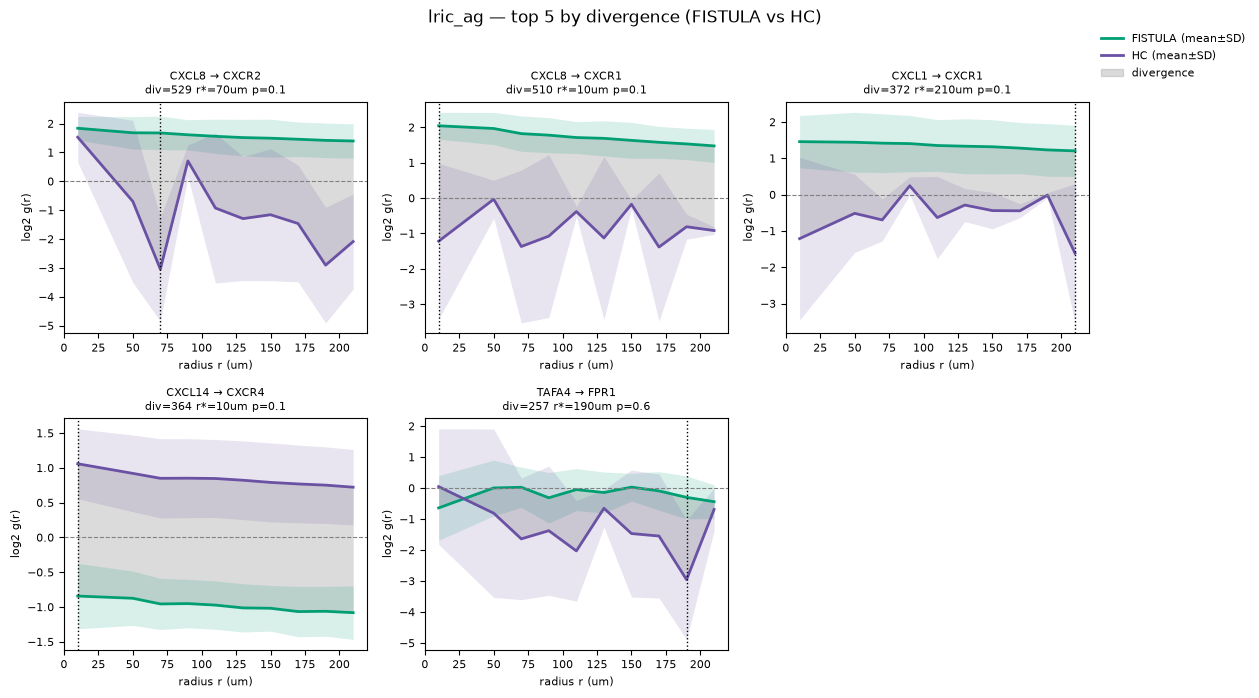

In [68]:
res = compare_curves(adata_list, "lric_ag", "FISTULA", "HC")
plot_divergence(adata_list, res, "lric_ag")        # per-feature: the statistic, drawn

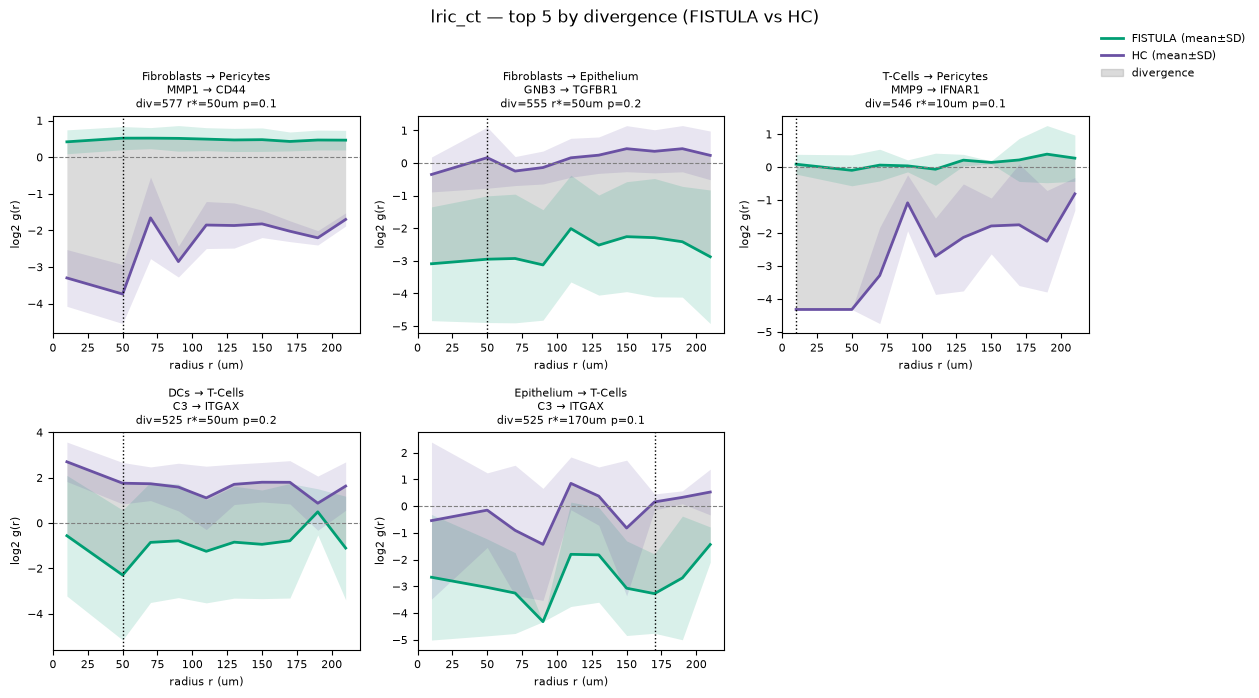

In [69]:
res = compare_curves(adata_list, "lric_ct", "FISTULA", "HC")
plot_divergence(adata_list, res, "lric_ct")        # per-feature: the statistic, drawn

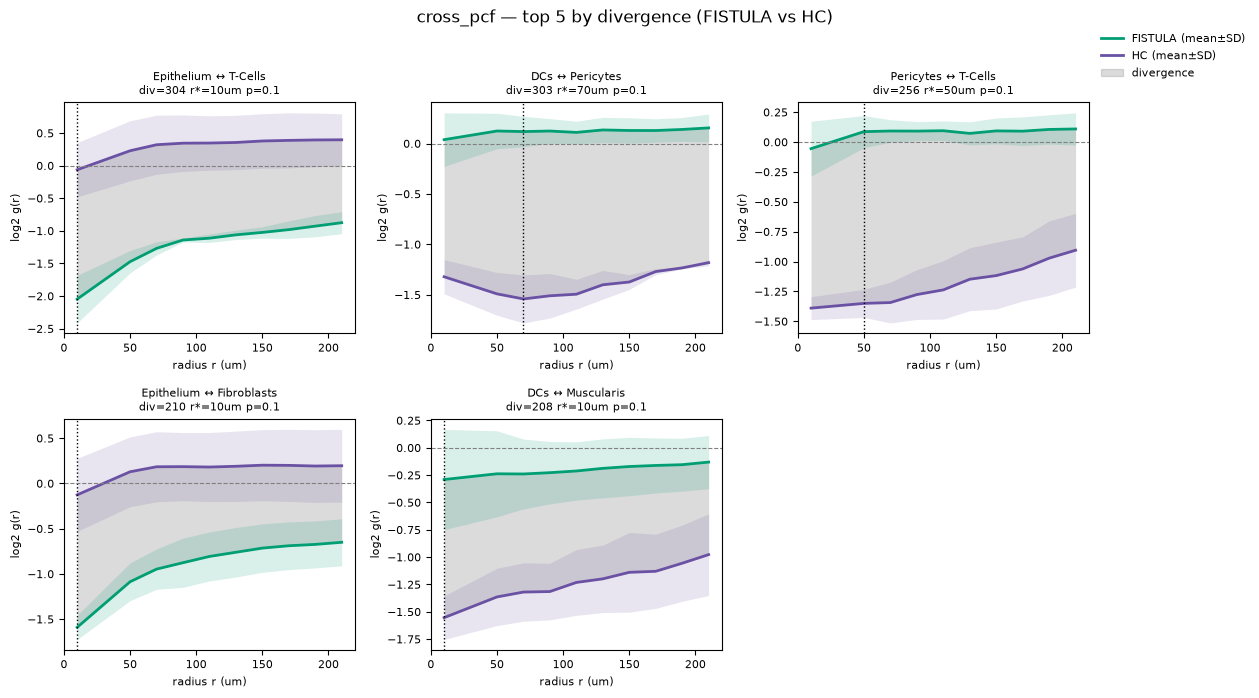

In [70]:
res = compare_curves(adata_list, "cross_pcf", "FISTULA", "HC")
plot_divergence(adata_list, res, "cross_pcf")        # per-feature: the statistic, drawn